**Importar bibliotecas**

In [185]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**Carregar os dados**

In [186]:
df = pd.read_csv("dados_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,conta_diaria
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


**Verificar estrutura do dataset**

In [187]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   str    
 1   Churn                      7032 non-null   float64
 2   customer.gender            7256 non-null   str    
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   str    
 5   customer.Dependents        7256 non-null   str    
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   str    
 8   phone.MultipleLines        7256 non-null   str    
 9   internet.InternetService   7256 non-null   str    
 10  internet.OnlineSecurity    7256 non-null   str    
 11  internet.OnlineBackup      7256 non-null   str    
 12  internet.DeviceProtection  7256 non-null   str    
 13  internet.TechSupport       7256 non-null   str    
 14  int

In [188]:
#Remover churn vazio
df = df.dropna(subset=["Churn"])

print(
"Interpretação: \n Foram removidos registros onde a variável Churn estava vazia.\n "
"Essa etapa garante que o conjunto de dados contenha apenas observações com informação válida\n "
"sobre cancelamento, evitando problemas durante a análise e o treinamento dos modelos.\n"
)

Interpretação: 
 Foram removidos registros onde a variável Churn estava vazia.
 Essa etapa garante que o conjunto de dados contenha apenas observações com informação válida
 sobre cancelamento, evitando problemas durante a análise e o treinamento dos modelos.



In [189]:
# Converter churn para inteiro
df["Churn"] = df["Churn"].astype(int)

print(
"Interpretação: \n A variável Churn foi convertida para o tipo inteiro para facilitar análises\n "
"estatísticas e o treinamento de modelos de Machine Learning, onde normalmente 0 representa\n "
"clientes que permaneceram e 1 representa clientes que cancelaram o serviço."
)

Interpretação: 
 A variável Churn foi convertida para o tipo inteiro para facilitar análises
 estatísticas e o treinamento de modelos de Machine Learning, onde normalmente 0 representa
 clientes que permaneceram e 1 representa clientes que cancelaram o serviço.


**Remover coluna irrelevante**

In [190]:
df = df.drop(columns=["customerID"], errors="ignore")

print(
"Interpretação: \n A coluna 'customerID' foi removida por ser apenas um identificador único de cliente.\n "
"Esse tipo de variável não contribui para a análise ou para o treinamento de modelos de Machine Learning,\n "
"pois não possui relação com o comportamento de churn."
)

Interpretação: 
 A coluna 'customerID' foi removida por ser apenas um identificador único de cliente.
 Esse tipo de variável não contribui para a análise ou para o treinamento de modelos de Machine Learning,
 pois não possui relação com o comportamento de churn.


**Criar novas variáveis (feature engineering)**

In [191]:
# Essas features melhoram o modelo
df["avg_monthly_spend"] = df["account.Charges.Total"] / (df["customer.tenure"] + 1)

df["cliente_novo"] = (df["customer.tenure"] < 12).astype(int)

print(
"Interpretação: \nForam criadas novas variáveis para enriquecer a análise.\n "
"'avg_monthly_spend' representa o gasto médio mensal estimado do cliente, "
"enquanto 'cliente_novo' identifica clientes com menos de 12 meses de contrato. \n"
"Essas features ajudam o modelo a capturar padrões de comportamento associados ao churn."
)

Interpretação: 
Foram criadas novas variáveis para enriquecer a análise.
 'avg_monthly_spend' representa o gasto médio mensal estimado do cliente, enquanto 'cliente_novo' identifica clientes com menos de 12 meses de contrato. 
Essas features ajudam o modelo a capturar padrões de comportamento associados ao churn.


**Encoding das variáveis categóricas**

In [192]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(
"Interpretação: \n As variáveis categóricas foram transformadas em variáveis numéricas utilizando "
"one-hot encoding (get_dummies). \n O parâmetro drop_first=True remove a primeira categoria de cada\n "
"variável para evitar multicolinearidade, tornando os dados adequados para modelos de Machine Learning."
)

Interpretação: 
 As variáveis categóricas foram transformadas em variáveis numéricas utilizando one-hot encoding (get_dummies). 
 O parâmetro drop_first=True remove a primeira categoria de cada
 variável para evitar multicolinearidade, tornando os dados adequados para modelos de Machine Learning.


**Ver proporção de churn**

In [193]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

print(
"\nInterpretação: \n O primeiro resultado mostra a quantidade absoluta de clientes em cada classe de Churn.\n "
"O segundo apresenta a proporção (percentual) de cada classe no dataset. \n"
"Essa análise ajuda a verificar se existe desbalanceamento entre clientes que cancelaram e os que permaneceram."
)

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Interpretação: 
 O primeiro resultado mostra a quantidade absoluta de clientes em cada classe de Churn.
 O segundo apresenta a proporção (percentual) de cada classe no dataset. 
Essa análise ajuda a verificar se existe desbalanceamento entre clientes que cancelaram e os que permaneceram.


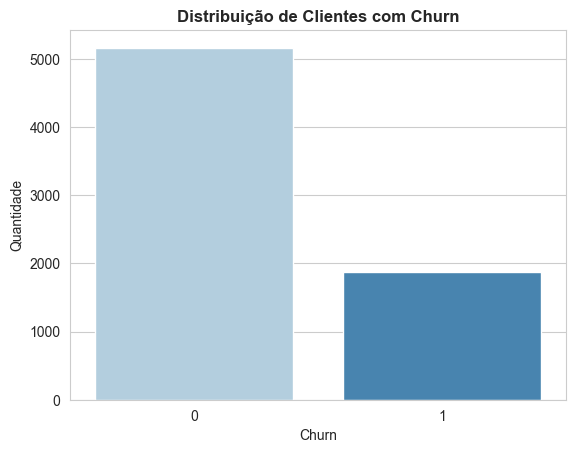

Interpretação:
O gráfico apresenta a distribuição de clientes que permaneceram na empresa e daqueles que cancelaram o serviço.
O valor 0 representa clientes que não realizaram churn (permaneceram na empresa), enquanto o valor 1 representa clientes que cancelaram o serviço.
Observa-se que a quantidade de clientes que permaneceram é significativamente maior que a de clientes que cancelaram.
Isso indica um certo desbalanceamento no conjunto de dados, onde a classe de não cancelamento é predominante.
Esse fator deve ser considerado durante a modelagem preditiva, pois modelos de Machine Learning podem ser influenciados por distribuições desbalanceadas.


In [194]:
sns.countplot(x="Churn", data=df, hue="Churn", palette="Blues", legend=False)
plt.title("Distribuição de Clientes com Churn", weight="bold")
plt.xlabel("Churn")
plt.ylabel("Quantidade")
plt.show()

print(
"Interpretação:\n"
"O gráfico apresenta a distribuição de clientes que permaneceram na empresa e daqueles que cancelaram o serviço.\n"
"O valor 0 representa clientes que não realizaram churn (permaneceram na empresa), enquanto o valor 1 representa clientes que cancelaram o serviço.\n"
"Observa-se que a quantidade de clientes que permaneceram é significativamente maior que a de clientes que cancelaram.\n"
"Isso indica um certo desbalanceamento no conjunto de dados, onde a classe de não cancelamento é predominante.\n"
"Esse fator deve ser considerado durante a modelagem preditiva, pois modelos de Machine Learning podem ser influenciados por distribuições desbalanceadas."
)

**Matriz de correlação**

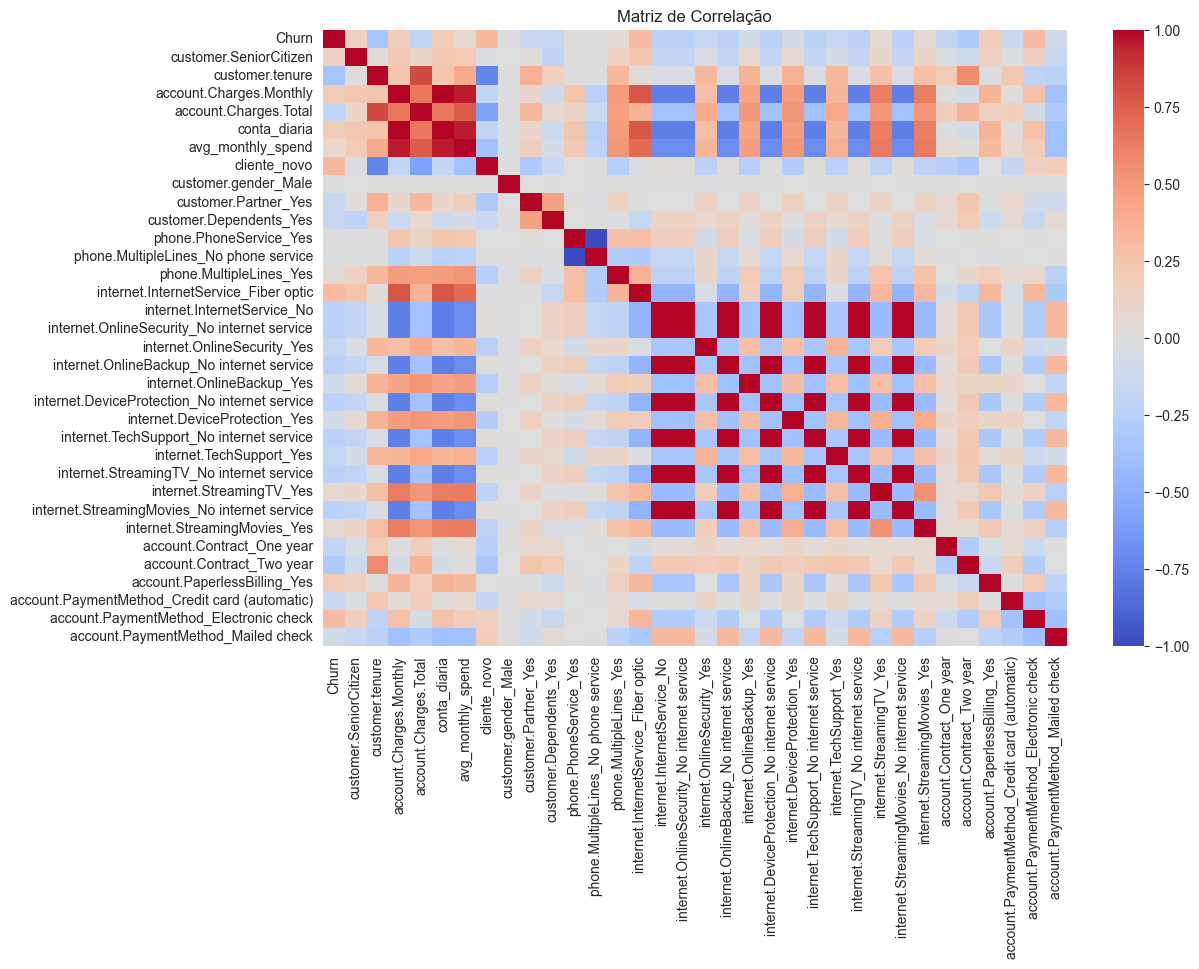

Interpretação:

Análise: cores mais quentes (vermelho) indicam correlação positiva entre as variáveis,
enquanto cores frias (azul) indicam correlação negativa. Valores próximos de 0 representam
baixa ou nenhuma relação linear entre as variáveis.

Vermelho → Correlação positiva entre variáveis
Azul → Correlação negativa
Cores claras → Baixa ou nenhuma correlação


In [195]:
corr = df_encoded.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Matriz de Correlação")

plt.show()

print(
    "Interpretação:\n"
"\nAnálise: cores mais quentes (vermelho) indicam correlação positiva entre as variáveis,\n"
"enquanto cores frias (azul) indicam correlação negativa. Valores próximos de 0 representam\n"
"baixa ou nenhuma relação linear entre as variáveis.\n"
"\n"

    "Vermelho → Correlação positiva entre variáveis\n"
    "Azul → Correlação negativa\n"
    "Cores claras → Baixa ou nenhuma correlação"
)

In [196]:
top_corr = corr["Churn"].sort_values(ascending=False).head(15)

print(top_corr)

print(
"\nInterpretação: \nAs variáveis com maior correlação positiva com o churn indicam maior probabilidade\n"
"de cancelamento. Destacam-se clientes novos, uso de internet fibra e pagamento por electronic check.\n "
"\nValores mensais mais altos também apresentam relação com maior evasão, enquanto variáveis próximas de "
"zero têm pouca influência no churn.\n"
)

Churn                                     1.000000
cliente_novo                              0.319816
internet.InternetService_Fiber optic      0.307463
account.PaymentMethod_Electronic check    0.301455
conta_diaria                              0.192858
account.Charges.Monthly                   0.192858
account.PaperlessBilling_Yes              0.191454
customer.SeniorCitizen                    0.150541
avg_monthly_spend                         0.070992
internet.StreamingTV_Yes                  0.063254
internet.StreamingMovies_Yes              0.060860
phone.MultipleLines_Yes                   0.040033
phone.PhoneService_Yes                    0.011691
customer.gender_Male                     -0.008545
phone.MultipleLines_No phone service     -0.011691
Name: Churn, dtype: float64

Interpretação: 
As variáveis com maior correlação positiva com o churn indicam maior probabilidade
de cancelamento. Destacam-se clientes novos, uso de internet fibra e pagamento por electronic check.
 
Valo

**Separar variáveis**

In [197]:
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

print(
"Interpretação: \n Os dados foram separados em variáveis explicativas (X) e variável alvo (y). \n"
"X contém as características dos clientes que serão usadas pelo modelo para aprender padrões,\n"
"enquanto y representa a variável Churn, que indica se o cliente cancelou ou não o serviço."
)

Interpretação: 
 Os dados foram separados em variáveis explicativas (X) e variável alvo (y). 
X contém as características dos clientes que serão usadas pelo modelo para aprender padrões,
enquanto y representa a variável Churn, que indica se o cliente cancelou ou não o serviço.


**Divisão treino / teste**

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(
"Interpretação: \nO conjunto de dados foi dividido em dados de treino e teste.\n "
"70% dos dados são usados para treinar o modelo e 30% para avaliar seu desempenho. \n"
"O parâmetro random_state=42 garante que a divisão seja reproduzível."
)

Interpretação: 
O conjunto de dados foi dividido em dados de treino e teste.
 70% dos dados são usados para treinar o modelo e 30% para avaliar seu desempenho. 
O parâmetro random_state=42 garante que a divisão seja reproduzível.


**Normalização (necessária para alguns modelos)**

In [199]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(
"Interpretação: \nFoi aplicada a padronização dos dados usando StandardScaler. \n"
"Esse processo ajusta as variáveis para terem média 0 e desvio padrão 1, \n"
"evitando que variáveis com escalas maiores influenciem mais o modelo. \n"
"O ajuste é feito apenas no conjunto de treino e depois aplicado ao conjunto de teste."
)

Interpretação: 
Foi aplicada a padronização dos dados usando StandardScaler. 
Esse processo ajusta as variáveis para terem média 0 e desvio padrão 1, 
evitando que variáveis com escalas maiores influenciem mais o modelo. 
O ajuste é feito apenas no conjunto de treino e depois aplicado ao conjunto de teste.


**Modelo 1 — Regressão Logística**

In [200]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(
"Interpretação: \nFoi treinado um modelo de Regressão Logística para prever o churn dos clientes. \n"
"O parâmetro max_iter=1000 garante que o algoritmo tenha iterações suficientes para convergir, \n"
"enquanto class_weight='balanced' ajusta os pesos das classes para lidar com possível desbalanceamento \n"
"entre clientes que cancelaram e os que permaneceram. Após o treinamento, o modelo gera previsões \n"
"para o conjunto de teste."
)

Interpretação: 
Foi treinado um modelo de Regressão Logística para prever o churn dos clientes. 
O parâmetro max_iter=1000 garante que o algoritmo tenha iterações suficientes para convergir, 
enquanto class_weight='balanced' ajusta os pesos das classes para lidar com possível desbalanceamento 
entre clientes que cancelaram e os que permaneceram. Após o treinamento, o modelo gera previsões 
para o conjunto de teste.


**Avaliação Regressão Logística**

In [201]:
print("Regressão Logística")

print("Acurácia:", accuracy_score(y_test, y_pred_log))
print("Precisão:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

print(
"\nInterpretação: \nAs métricas avaliam o desempenho do modelo.\n "
"Acurácia indica a proporção total de previsões corretas.\n"
"Precisão mede quantos dos clientes previstos como churn realmente cancelaram. \n"
"Recall mostra a capacidade do modelo de identificar clientes que realmente cancelaram. \n"
"O F1-score é o equilíbrio entre precisão e recall, sendo útil quando há desbalanceamento entre classes."
)

Regressão Logística
Acurácia: 0.7345971563981043
Precisão: 0.497737556561086
Recall: 0.7913669064748201
F1-score: 0.6111111111111112
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1554
           1       0.50      0.79      0.61       556

    accuracy                           0.73      2110
   macro avg       0.70      0.75      0.70      2110
weighted avg       0.80      0.73      0.75      2110


Interpretação: 
As métricas avaliam o desempenho do modelo.
 Acurácia indica a proporção total de previsões corretas.
Precisão mede quantos dos clientes previstos como churn realmente cancelaram. 
Recall mostra a capacidade do modelo de identificar clientes que realmente cancelaram. 
O F1-score é o equilíbrio entre precisão e recall, sendo útil quando há desbalanceamento entre classes.


**Matriz de confusão**

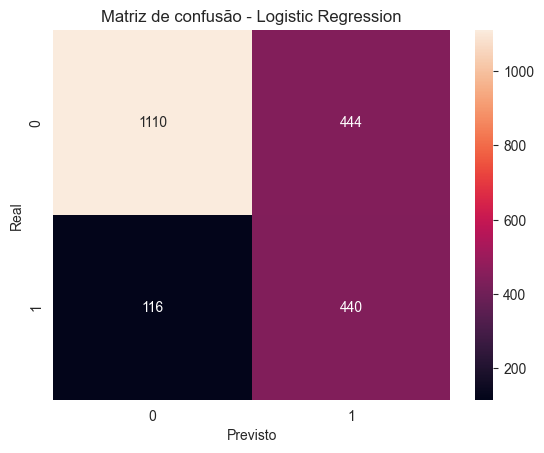

Interpretação:
O modelo classificou corretamente 1110 clientes que não cancelaram e 440 que cancelaram.
Também houve 444 falsos positivos (previstos como churn, mas não cancelaram) e 116 falsos negativos.
Isso indica que o modelo consegue identificar boa parte dos clientes com churn, porém ainda gera alguns alertas incorretos.


In [213]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusão - Logistic Regression")

plt.ylabel("Real")
plt.xlabel("Previsto")

plt.show()

print(
"Interpretação:\n"
"O modelo classificou corretamente 1110 clientes que não cancelaram e 440 que cancelaram.\n"
"Também houve 444 falsos positivos (previstos como churn, mas não cancelaram) e 116 falsos negativos.\n"
"Isso indica que o modelo consegue identificar boa parte dos clientes com churn, porém ainda gera alguns alertas incorretos."
)

**Modelo 2 — Random Forest**

In [203]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(
"Interpretação: \n Foi treinado um modelo Random Forest para prever o churn.\n "
"O algoritmo cria várias árvores de decisão (n_estimators=500) e combina seus resultados\n "
"para melhorar a precisão das previsões. O parâmetro max_depth controla a complexidade "
"das árvores, enquanto min_samples_split ajuda a evitar overfitting.\n "
"O class_weight='balanced' ajusta o modelo para lidar com possível desbalanceamento entre as classes."
)

Interpretação: 
 Foi treinado um modelo Random Forest para prever o churn.
 O algoritmo cria várias árvores de decisão (n_estimators=500) e combina seus resultados
 para melhorar a precisão das previsões. O parâmetro max_depth controla a complexidade das árvores, enquanto min_samples_split ajuda a evitar overfitting.
 O class_weight='balanced' ajusta o modelo para lidar com possível desbalanceamento entre as classes.


**Avaliação Random Forest**

In [204]:
print("Random Forest")

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(
"\nInterpretação: \n Essas métricas mostram o desempenho do modelo Random Forest.\n "
"A acurácia indica a proporção total de previsões corretas.\n "
"A precisão mostra quantos clientes previstos como churn realmente cancelaram.\n "
"O recall indica a capacidade do modelo de identificar clientes que realmente cancelaram.\n "
"O F1-score representa o equilíbrio entre precisão e recall, sendo uma métrica importante\n "
"quando há desbalanceamento entre as classes."
)

Random Forest
Acurácia: 0.7672985781990521
Precisão: 0.5464949928469242
Recall: 0.6870503597122302
F1-score: 0.6087649402390438
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      1554
           1       0.55      0.69      0.61       556

    accuracy                           0.77      2110
   macro avg       0.71      0.74      0.72      2110
weighted avg       0.79      0.77      0.77      2110


Interpretação: 
 Essas métricas mostram o desempenho do modelo Random Forest.
 A acurácia indica a proporção total de previsões corretas.
 A precisão mostra quantos clientes previstos como churn realmente cancelaram.
 O recall indica a capacidade do modelo de identificar clientes que realmente cancelaram.
 O F1-score representa o equilíbrio entre precisão e recall, sendo uma métrica importante
 quando há desbalanceamento entre as classes.


**Matriz de confusão**

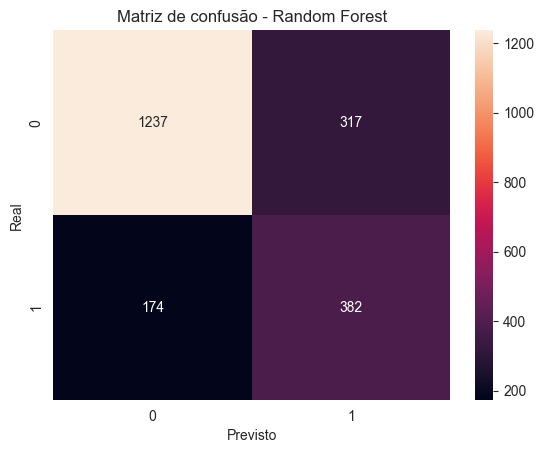

Interpretação:
O modelo classificou corretamente 1237 clientes que não cancelaram e 382 que cancelaram.
Também ocorreram 317 falsos positivos (previstos como churn, mas não cancelaram) e 174 falsos negativos.
Isso indica que o modelo possui boa capacidade de identificar clientes sem churn, mas ainda perde parte dos clientes que realmente cancelam.


In [214]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusão - Random Forest")

plt.ylabel("Real")
plt.xlabel("Previsto")

plt.show()

print(
"Interpretação:\n"
"O modelo classificou corretamente 1237 clientes que não cancelaram e 382 que cancelaram.\n"
"Também ocorreram 317 falsos positivos (previstos como churn, mas não cancelaram) e 174 falsos negativos.\n"
"Isso indica que o modelo possui boa capacidade de identificar clientes sem churn, mas ainda perde parte dos clientes que realmente cancelam."
)

**Modelo 3 — Gradient Boosting**

In [206]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print(
"Interpretação: \n Foi treinado um modelo Gradient Boosting para prever churn.\n "
"Esse algoritmo cria várias árvores de decisão sequencialmente, onde cada nova árvore\n "
"corrige os erros da anterior, melhorando gradualmente a capacidade de previsão do modelo."
)

Interpretação: 
 Foi treinado um modelo Gradient Boosting para prever churn.
 Esse algoritmo cria várias árvores de decisão sequencialmente, onde cada nova árvore
 corrige os erros da anterior, melhorando gradualmente a capacidade de previsão do modelo.


**Avaliação Gradient Boosting**

In [207]:
print("Gradient Boosting")

print("Acurácia:", accuracy_score(y_test, y_pred_gb))
print("Precisão:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))

print(
"\nInterpretação: \n As métricas apresentam o desempenho do modelo Gradient Boosting.\n "
"A acurácia indica a proporção total de previsões corretas.\n "
"A precisão mede quantos clientes previstos como churn realmente cancelaram.\n "
"O recall mostra a capacidade do modelo em identificar clientes que realmente cancelaram.\n "
"O F1-score representa o equilíbrio entre precisão e recall, sendo útil quando há desbalanceamento entre as classes."
)

Gradient Boosting
Acurácia: 0.795734597156398
Precisão: 0.6267748478701826
Recall: 0.5557553956834532
F1-score: 0.5891325071496664
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1554
           1       0.63      0.56      0.59       556

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.79      2110


Interpretação: 
 As métricas apresentam o desempenho do modelo Gradient Boosting.
 A acurácia indica a proporção total de previsões corretas.
 A precisão mede quantos clientes previstos como churn realmente cancelaram.
 O recall mostra a capacidade do modelo em identificar clientes que realmente cancelaram.
 O F1-score representa o equilíbrio entre precisão e recall, sendo útil quando há desbalanceamento entre as classes.


**Matriz de confusão**

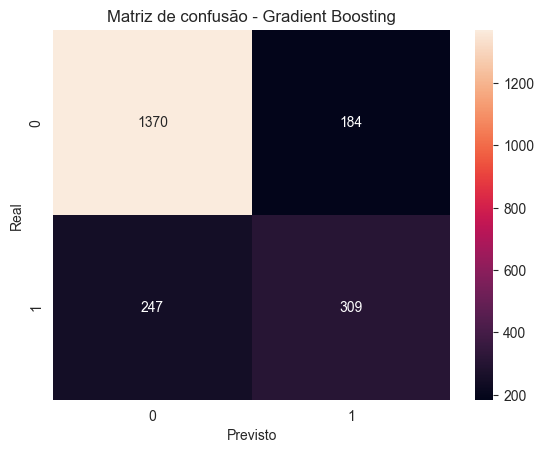

Interpretação:
O modelo classificou corretamente 1370 clientes que não cancelaram e 309 que cancelaram.
Também ocorreram 184 falsos positivos e 247 falsos negativos.
Isso mostra que o modelo identifica bem clientes sem churn, mas ainda deixa escapar parte dos clientes que realmente cancelam.


In [215]:
cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusão - Gradient Boosting")

plt.ylabel("Real")
plt.xlabel("Previsto")

plt.show()

print(
"Interpretação:\n"
"O modelo classificou corretamente 1370 clientes que não cancelaram e 309 que cancelaram.\n"
"Também ocorreram 184 falsos positivos e 247 falsos negativos.\n"
"Isso mostra que o modelo identifica bem clientes sem churn, mas ainda deixa escapar parte dos clientes que realmente cancelam."
)

**Importância das variáveis**

In [209]:
importances = rf_model.feature_importances_

features = pd.Series(importances, index=X.columns)

top_features = features.sort_values(ascending=False).head(10)

print(top_features)

print(
"\nInterpretação: \n O resultado mostra as 10 variáveis mais importantes para o modelo Random Forest na previsão de churn.\n "
"Quanto maior o valor de importância, maior a influência da variável nas decisões do modelo para classificar "
"se um cliente tende ou não a cancelar o serviço."
)

customer.tenure                           0.127681
account.Charges.Total                     0.113576
avg_monthly_spend                         0.089598
account.Charges.Monthly                   0.081179
conta_diaria                              0.080447
account.Contract_Two year                 0.078777
internet.InternetService_Fiber optic      0.052725
cliente_novo                              0.047296
account.PaymentMethod_Electronic check    0.039894
account.Contract_One year                 0.032226
dtype: float64

Interpretação: 
 O resultado mostra as 10 variáveis mais importantes para o modelo Random Forest na previsão de churn.
 Quanto maior o valor de importância, maior a influência da variável nas decisões do modelo para classificar se um cliente tende ou não a cancelar o serviço.


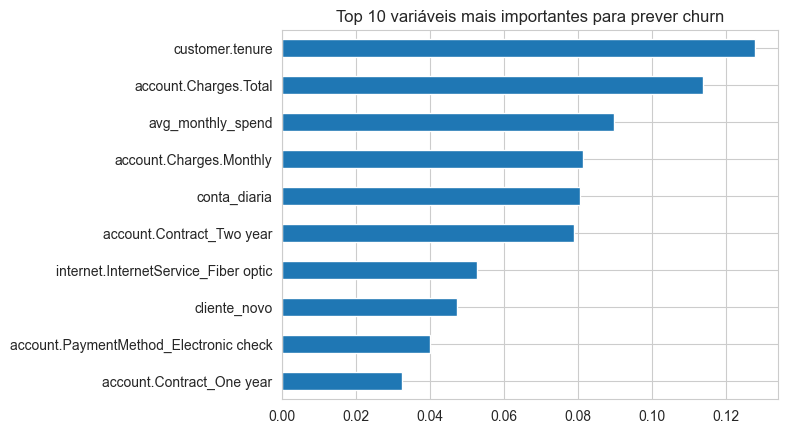

Interpretação: 
O gráfico apresenta as 10 variáveis mais importantes para a previsão de churn segundo o modelo Random Forest. 
Variáveis com maior valor de importância têm maior influência nas decisões do modelo para identificar clientes com maior risco de cancelamento.


In [216]:
# Gráfico
top_features.sort_values().plot(kind="barh")

plt.title("Top 10 variáveis mais importantes para prever churn")

plt.show()

print(
"Interpretação: \nO gráfico apresenta as 10 variáveis mais importantes para a previsão de churn segundo o modelo Random Forest. \n"
"Variáveis com maior valor de importância têm maior influência nas decisões do modelo para identificar clientes com maior risco de cancelamento."
)

In [211]:
results = pd.DataFrame({

    "Modelo":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_gb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_gb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_gb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_gb)
    ]
})

print(results)

print(
"\nInterpretação: \n A tabela apresenta a comparação de desempenho entre os modelos avaliados. \n"
"As métricas de acurácia, precisão, recall e F1-score ajudam a identificar qual modelo\n "
"possui melhor capacidade de prever o churn dos clientes."
)

                Modelo  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.734597   0.497738  0.791367  0.611111
1        Random Forest  0.767299   0.546495  0.687050  0.608765
2    Gradient Boosting  0.795735   0.626775  0.555755  0.589133

Interpretação: 
 A tabela apresenta a comparação de desempenho entre os modelos avaliados. 
As métricas de acurácia, precisão, recall e F1-score ajudam a identificar qual modelo
 possui melhor capacidade de prever o churn dos clientes.
